In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

I0000 00:00:1778546316.835524  151231 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
dataset = pd.read_csv(r'/home/atharva/Downloads/Google_Stock_Price_Train.csv')

In [9]:
training_set = dataset.iloc[:, 1:2].values
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# Create Data for RNN
x_train = []
y_train = []

for i in range(60, 1258):

    x_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape Data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build RNN Model
model = Sequential()

# RNN Layer
model.add(SimpleRNN(units=50, activation='tanh', input_shape=(x_train.shape[1],1)))

# Output Layer
model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


E0000 00:00:1778546701.975284  151231 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/atharva/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Train Model
model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2057
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013
Epoc

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Predicted Stock Prices:

Actual Price = 325.5
Predicted Price = 326.83536

Actual Price = 324.66
Predicted Price = 327.66464

Actual Price = 319.19
Predicted Price = 327.50305

Actual Price = 321.5
Predicted Price = 329.4733

Actual Price = 318.03
Predicted Price = 326.76413

Actual Price = 314.94
Predicted Price = 326.43854

Actual Price = 313.07
Predicted Price = 325.46863

Actual Price = 315.58
Predicted Price = 320.6521

Actual Price = 315.8
Predicted Price = 316.92136

Actual Price = 319.98
Predicted Price = 314.17093



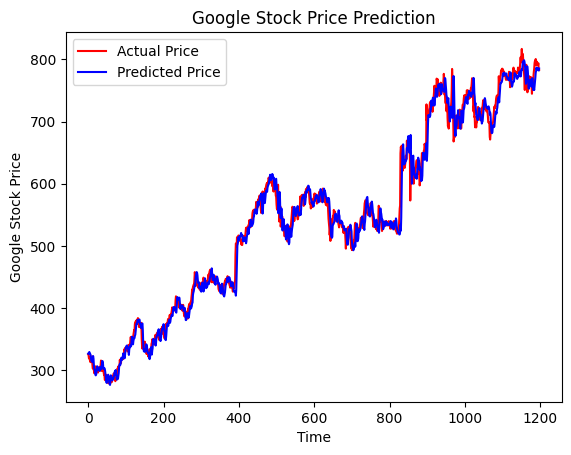

In [11]:
predicted_stock_price = model.predict(x_train)

# Convert Back to Original Values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Display Predictions
print("\nPredicted Stock Prices:\n")

for i in range(10):

    print("Actual Price =", training_set[i+60][0])
    print("Predicted Price =", predicted_stock_price[i][0])
    print()

# Plot Graph
plt.plot(training_set[60:], color='red', label='Actual Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google Stock Price")

plt.legend()
plt.show()